In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("../data/raw/WA_Fn-UseC_-HR-Employee-Attrition.csv")

df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,Gender,HourlyRate,JobInvolvement,JobLevel,JobRole,JobSatisfaction,MaritalStatus,MonthlyIncome,MonthlyRate,NumCompaniesWorked,Over18,OverTime,PercentSalaryHike,PerformanceRating,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,2,Female,94,3,2,Sales Executive,4,Single,5993,19479,8,Y,Yes,11,3,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,3,Male,61,2,2,Research Scientist,2,Married,5130,24907,1,Y,No,23,4,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,4,Male,92,2,1,Laboratory Technician,3,Single,2090,2396,6,Y,Yes,15,3,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,4,Female,56,3,1,Research Scientist,3,Married,2909,23159,1,Y,Yes,11,3,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,1,Male,40,3,1,Laboratory Technician,2,Married,3468,16632,9,Y,No,12,3,4,80,1,6,3,3,2,2,2,2


In [3]:
print("Shape:", df.shape)

Shape: (1470, 35)


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [7]:
df["Attrition"].value_counts(normalize=True) * 100

Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64

## Observation: Target Variable (Attrition)

- Employees who stayed: **83.88%**
- Employees who left: **16.12%**

### Insight
The dataset is imbalanced, with the majority of employees staying in the organization. Therefore, accuracy alone will not be a reliable evaluation metric. During model evaluation, we will focus on Precision, Recall, F1-score, and ROC-AUC to assess performance, especially for predicting employee attrition.

In [8]:
df.describe(include="object")

C:\Users\shara\AppData\Local\Temp\ipykernel_17836\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [9]:
df["EmployeeCount"].value_counts()

EmployeeCount
1    1470
Name: count, dtype: int64

In [10]:
df["StandardHours"].value_counts()

StandardHours
80    1470
Name: count, dtype: int64

In [11]:
df["EmployeeNumber"].nunique()

1470

In [12]:
df["Over18"].value_counts()

Over18
Y    1470
Name: count, dtype: int64

## Exploratory Data Analysis (EDA)

C:\Users\shara\AppData\Local\Temp\ipykernel_17836\1063480073.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=df, x="Attrition", palette="Set2")


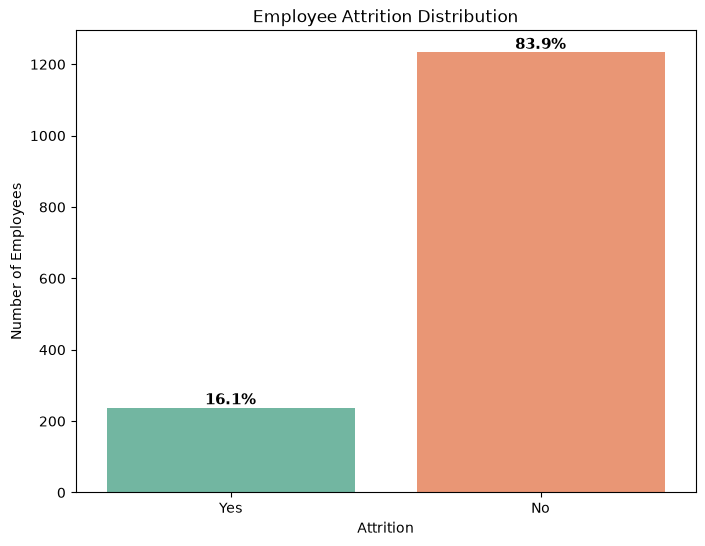

In [13]:
plt.figure(figsize=(8,6))

ax = sns.countplot(data=df, x="Attrition", palette="Set2")

total = len(df)

for p in ax.patches:
    percentage = f'{100 * p.get_height()/total:.1f}%'
    ax.annotate(
        percentage,
        (p.get_x() + p.get_width()/2, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=11,
        fontweight='bold'
    )

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Number of Employees")
plt.show()

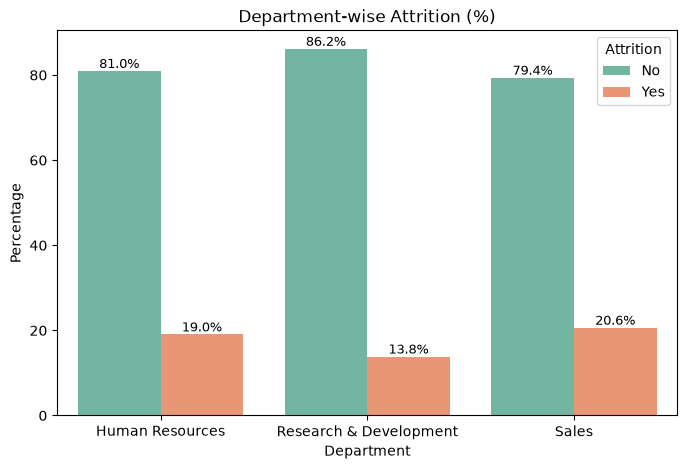

In [14]:
department_attrition = (
    df.groupby("Department")["Attrition"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=department_attrition,
    x="Department",
    y="Percentage",
    hue="Attrition",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=9)

plt.title("Department-wise Attrition (%)")
plt.ylabel("Percentage")
plt.xlabel("Department")
plt.show()

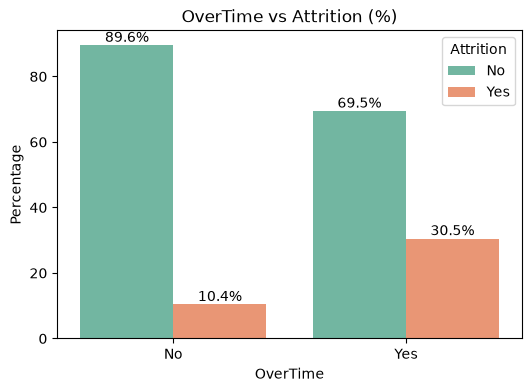

In [15]:
overtime_attrition = (
    df.groupby("OverTime")["Attrition"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

plt.figure(figsize=(6,4))

ax = sns.barplot(
    data=overtime_attrition,
    x="OverTime",
    y="Percentage",
    hue="Attrition",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("OverTime vs Attrition (%)")
plt.ylabel("Percentage")
plt.show()

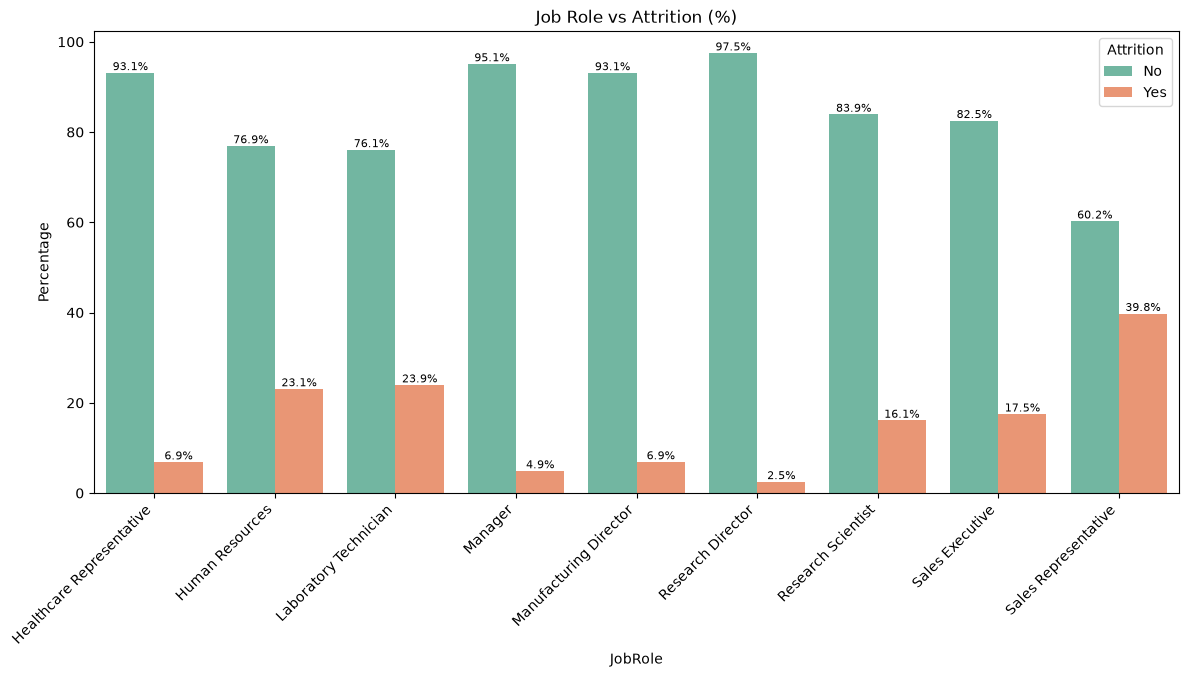

In [16]:
jobrole_attrition = (
    df.groupby("JobRole")["Attrition"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

plt.figure(figsize=(14,6))

ax = sns.barplot(
    data=jobrole_attrition,
    x="JobRole",
    y="Percentage",
    hue="Attrition",
    palette="Set2"
)

plt.xticks(rotation=45, ha="right")

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8)

plt.title("Job Role vs Attrition (%)")
plt.ylabel("Percentage")
plt.show()

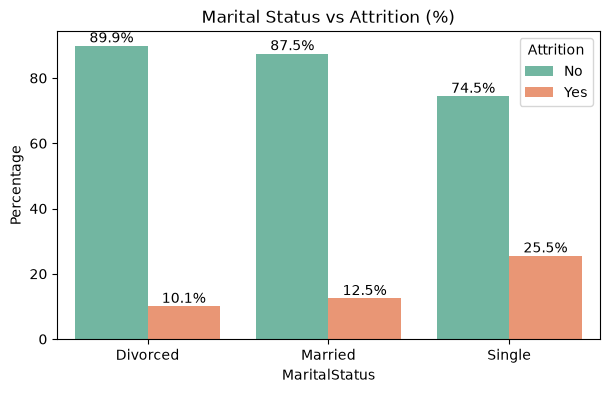

In [17]:
marital_attrition = (
    df.groupby("MaritalStatus")["Attrition"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

plt.figure(figsize=(7,4))

ax = sns.barplot(
    data=marital_attrition,
    x="MaritalStatus",
    y="Percentage",
    hue="Attrition",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Marital Status vs Attrition (%)")
plt.ylabel("Percentage")
plt.show()

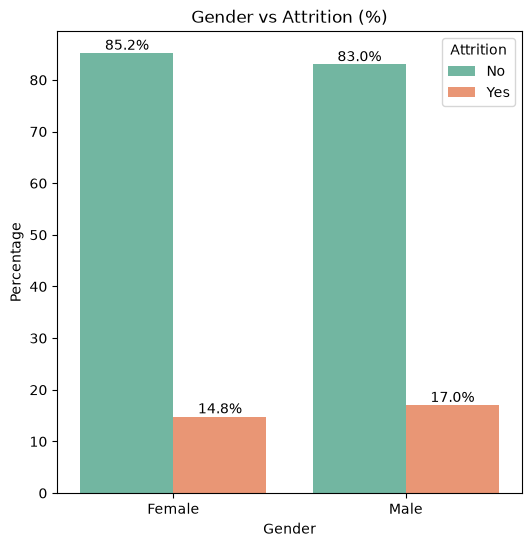

In [18]:
gender_attrition = (
    df.groupby("Gender")["Attrition"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

plt.figure(figsize=(6,6))

ax = sns.barplot(
    data=gender_attrition,
    x="Gender",
    y="Percentage",
    hue="Attrition",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Gender vs Attrition (%)")
plt.ylabel("Percentage")
plt.show()

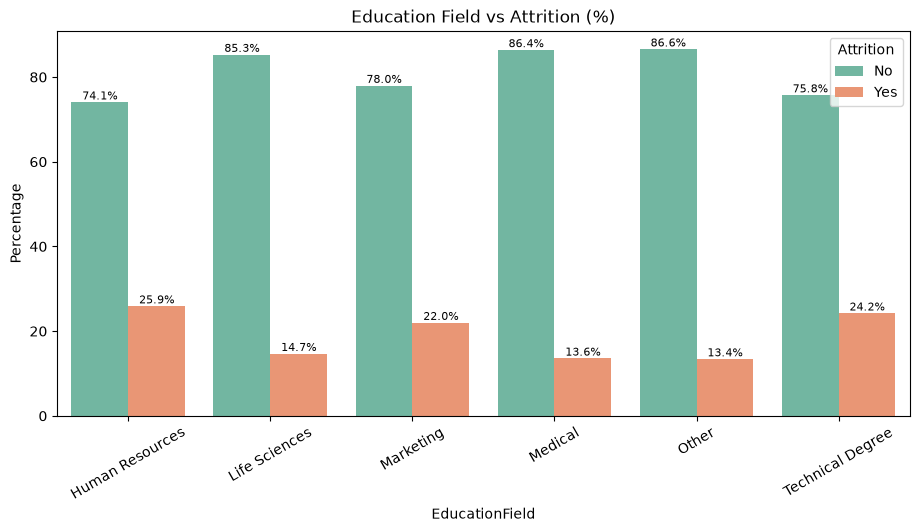

In [19]:
education_attrition = (
    df.groupby("EducationField")["Attrition"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

plt.figure(figsize=(11,5))

ax = sns.barplot(
    data=education_attrition,
    x="EducationField",
    y="Percentage",
    hue="Attrition",
    palette="Set2"
)

plt.xticks(rotation=30)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", fontsize=8)

plt.title("Education Field vs Attrition (%)")
plt.ylabel("Percentage")
plt.show()

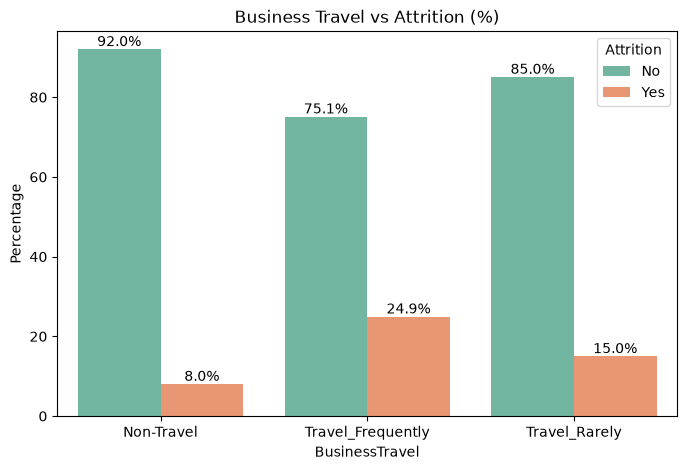

In [20]:
travel_attrition = (
    df.groupby("BusinessTravel")["Attrition"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=travel_attrition,
    x="BusinessTravel",
    y="Percentage",
    hue="Attrition",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Business Travel vs Attrition (%)")
plt.show()

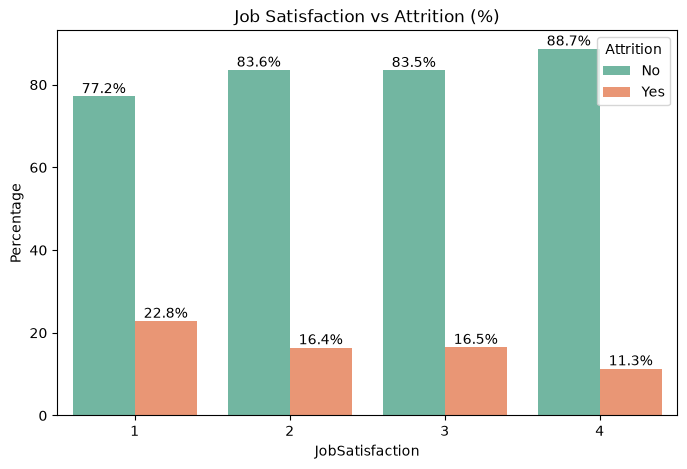

In [21]:
job_sat = (
    df.groupby("JobSatisfaction")["Attrition"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=job_sat,
    x="JobSatisfaction",
    y="Percentage",
    hue="Attrition",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Job Satisfaction vs Attrition (%)")
plt.show()

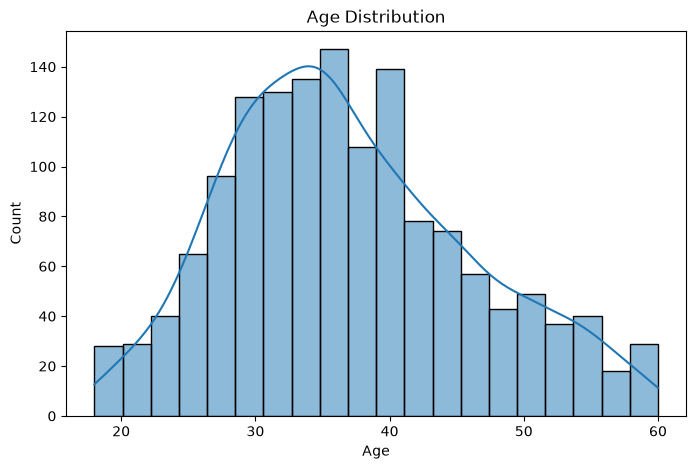

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df, x="Age", kde=True, bins=20)

plt.title("Age Distribution")
plt.show()

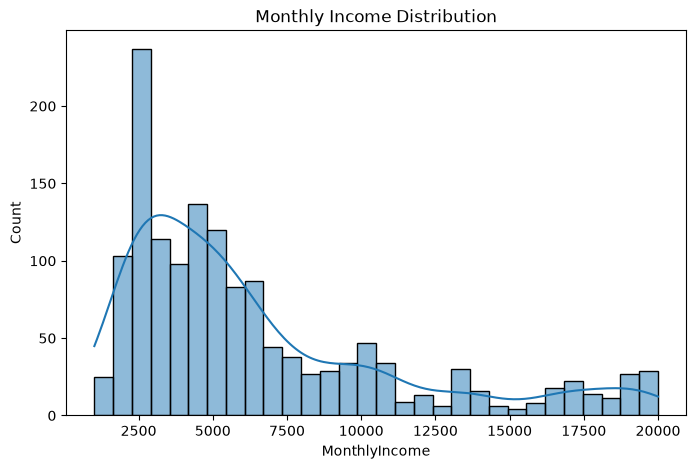

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(df, x="MonthlyIncome", kde=True, bins=30)

plt.title("Monthly Income Distribution")
plt.show()

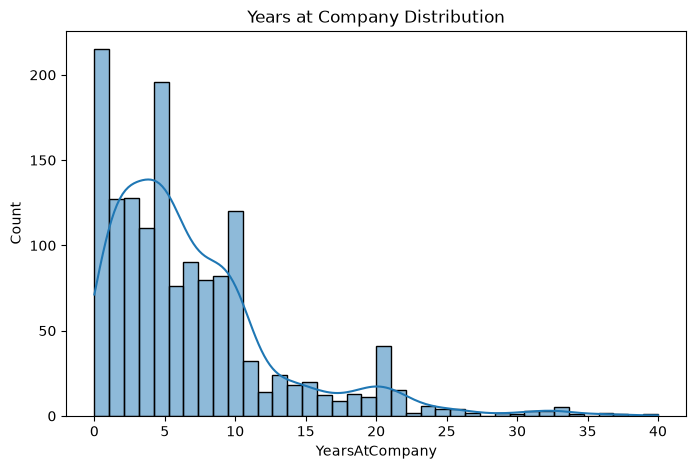

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df, x="YearsAtCompany", kde=True)

plt.title("Years at Company Distribution")
plt.show()

C:\Users\shara\AppData\Local\Temp\ipykernel_17836\607262823.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


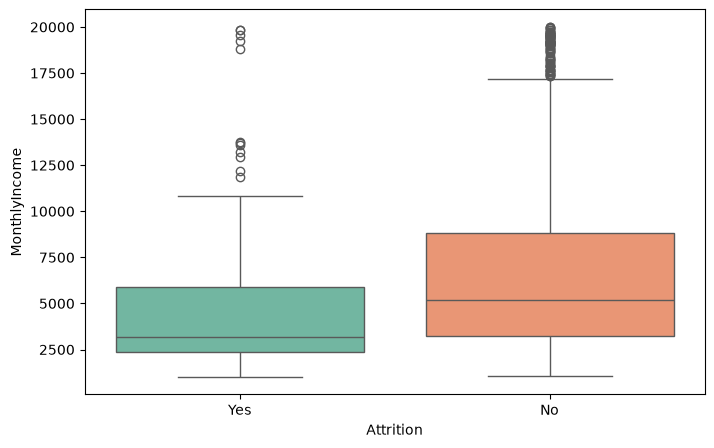

In [25]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="MonthlyIncome",
    palette="Set2"
)

plt.show()

C:\Users\shara\AppData\Local\Temp\ipykernel_17836\2366288698.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


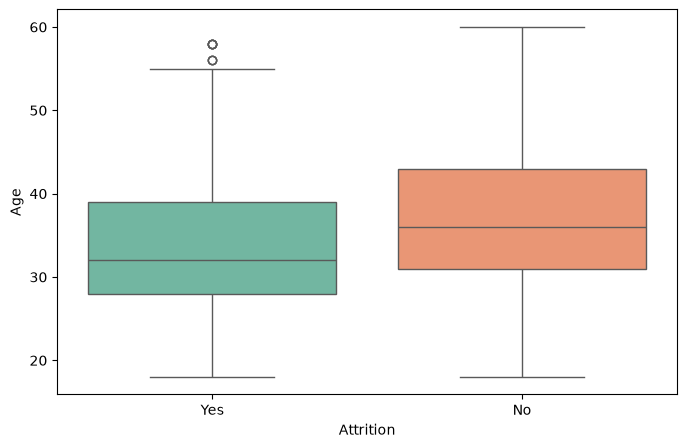

In [26]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="Age",
    palette="Set2"
)

plt.show()

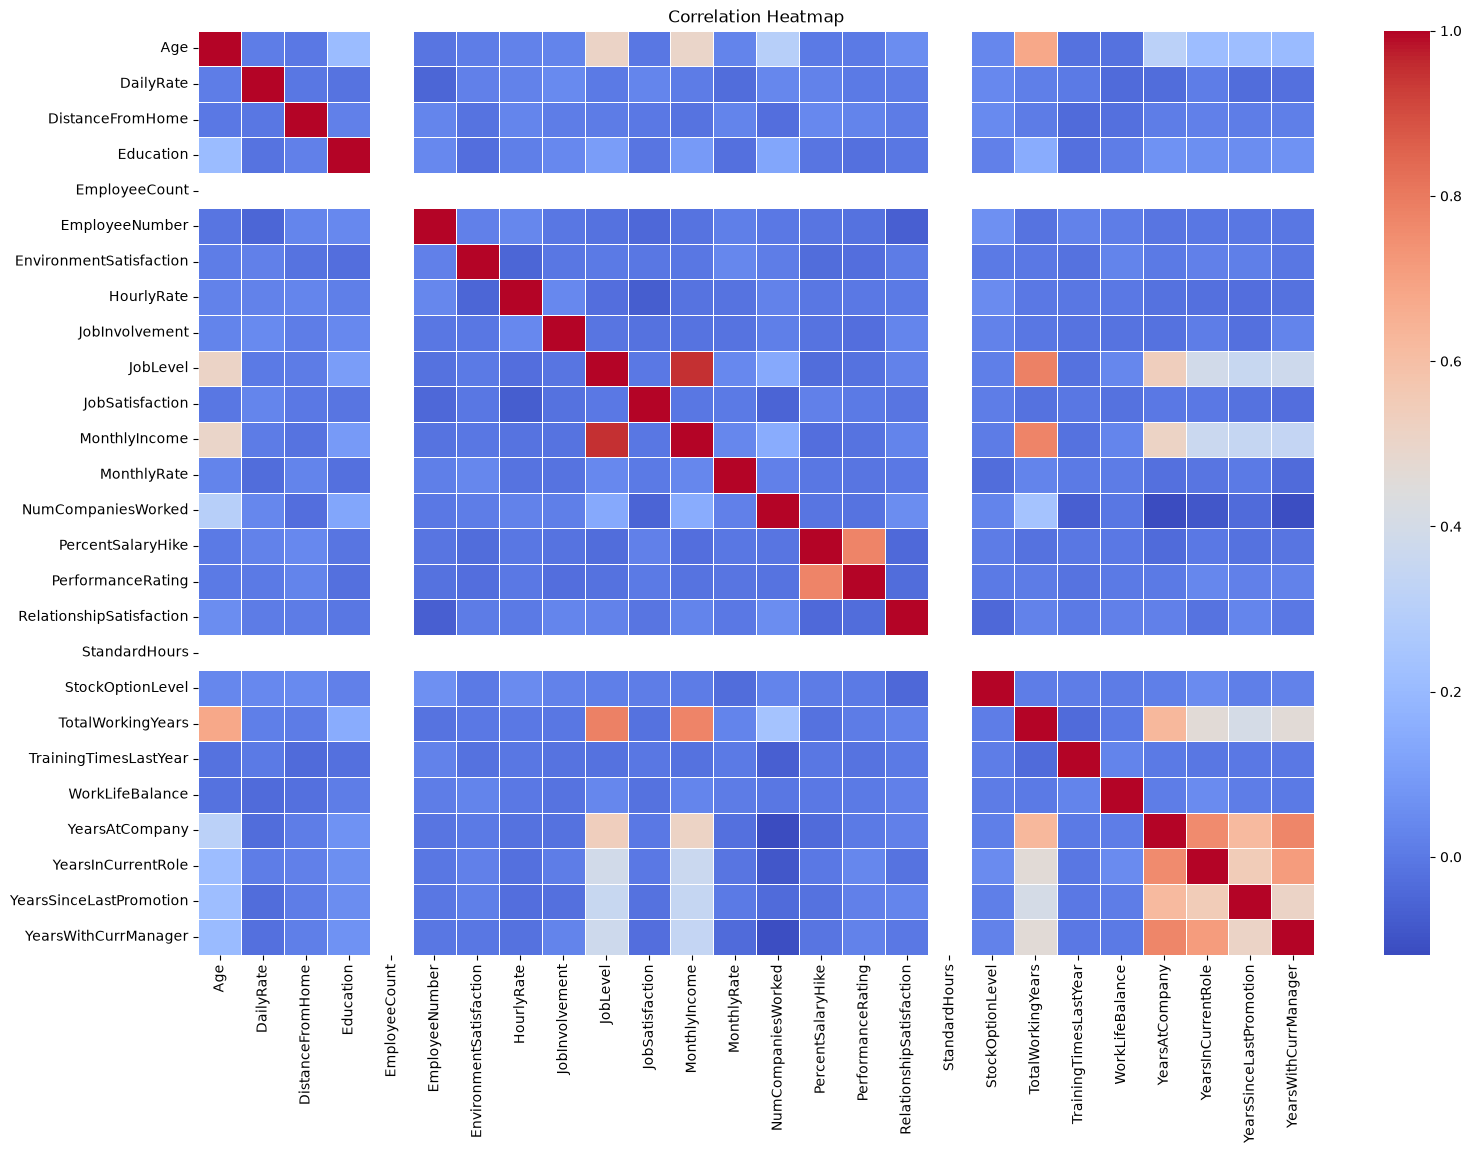

In [27]:
plt.figure(figsize=(18,12))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    linewidths=.5
)

plt.title("Correlation Heatmap")
plt.show()

C:\Users\shara\AppData\Local\Temp\ipykernel_17836\2833429164.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


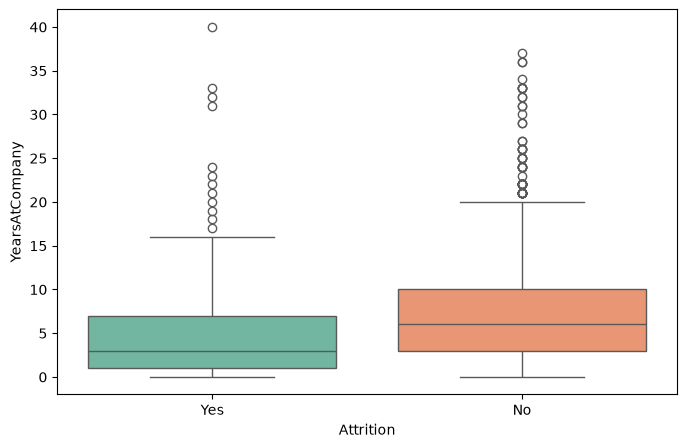

In [28]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=df,
    x="Attrition",
    y="YearsAtCompany",
    palette="Set2"
)

plt.show()

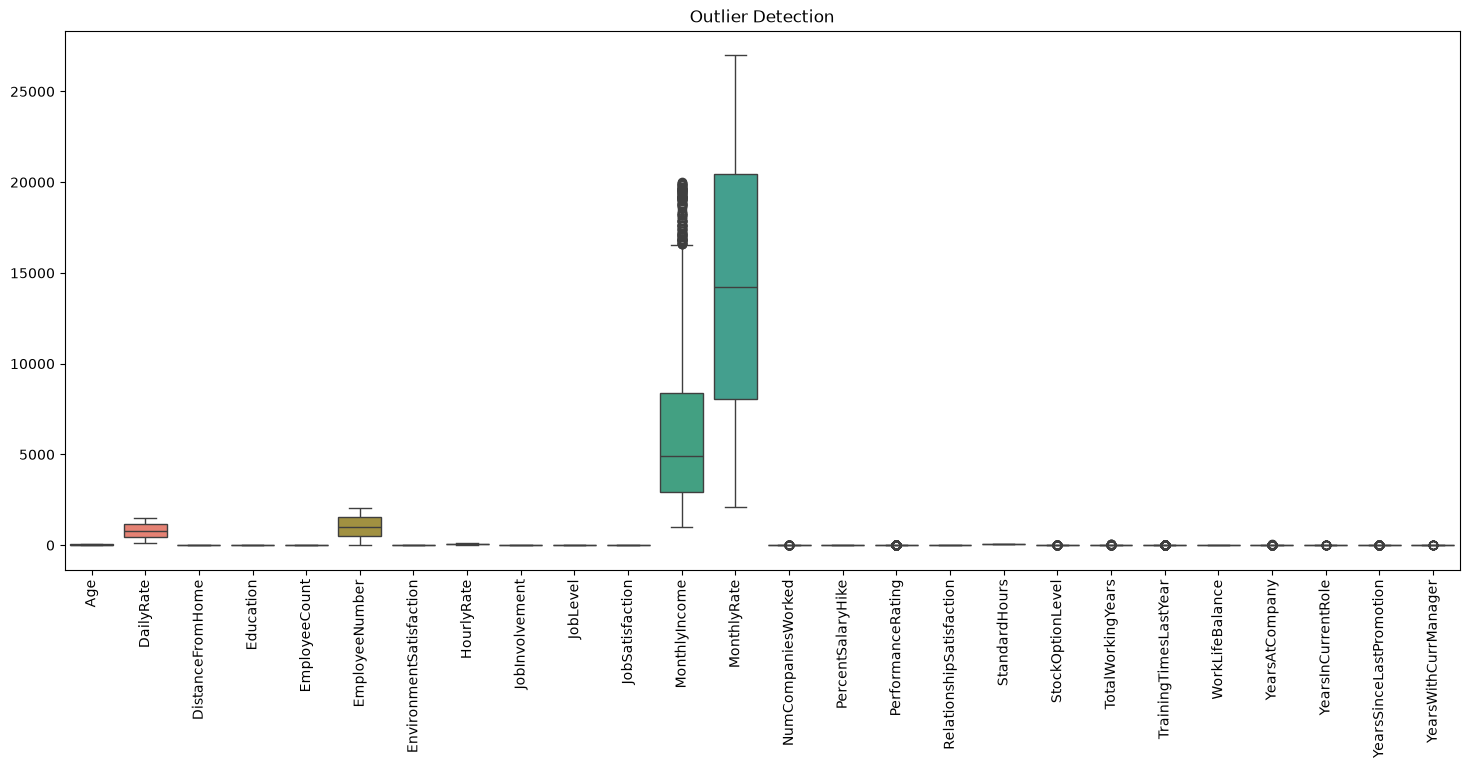

In [29]:
plt.figure(figsize=(18,7))

sns.boxplot(data=df.select_dtypes(include="number"))

plt.xticks(rotation=90)

plt.title("Outlier Detection")
plt.show()

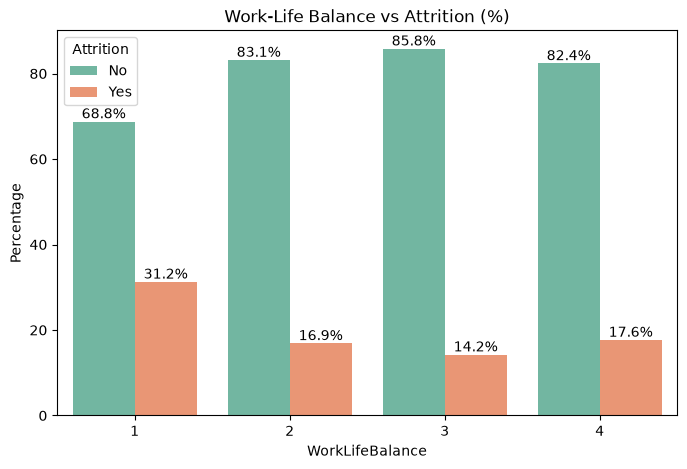

In [30]:
wlb = (
    df.groupby("WorkLifeBalance")["Attrition"]
      .value_counts(normalize=True)
      .mul(100)
      .rename("Percentage")
      .reset_index()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    data=wlb,
    x="WorkLifeBalance",
    y="Percentage",
    hue="Attrition",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%")

plt.title("Work-Life Balance vs Attrition (%)")
plt.show()

In [31]:
# Create a copy
df_clean = df.copy()

# Remove constant and ID columns
df_clean = df_clean.drop(columns=[
    "EmployeeCount",
    "EmployeeNumber",
    "Over18",
    "StandardHours"
])

# Save the cleaned dataset
df_clean.to_csv(
    "../data/processed/employee_attrition_clean.csv",
    index=False
)

In [32]:
df_clean.shape


(1470, 31)